# Volume flow: close loops in every plane

What changes when the grid has a third neighbor direction?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

For each oriented face $C$, compute residue $r_C$ from wrapped edge steps.
Integer corrections satisfy $Bk=-r$, where $B$ contains the face-edge signs.
Minimize a correction cost subject to these constraints.

In 2-D a pixel edge has at most two adjacent cells, giving the familiar network
structure. A 3-D interior edge can belong to four faces. A planar flow solver
cannot simply treat those four faces as its two arc endpoints.

1. Enumerate grid edges and faces in all coordinate planes.
2. Build $Bk=-r$ and a correction objective.
3. Use planar flow in 2-D or the integer search for a small volume.
4. Integrate a feasible correction and inspect `info.proven`.

A $2\times2\times2$ cube has 8 vertices, 12 edges, and 6 square faces.
There are only $12-8+1=5$ independent cycles; one face equation is redundant.

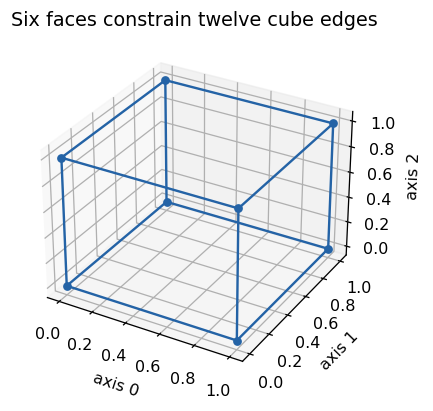

In [2]:
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure(figsize=(5,4)); ax=fig.add_subplot(111,projection='3d')
nodes=np.array(list(np.ndindex(2,2,2)))
for a in nodes:
    ax.scatter(*a,color='#2463a6')
    for axis in range(3):
        b=a.copy(); b[axis]+=1
        if b[axis]<2: ax.plot(*np.array([a,b]).T,color='#2463a6')
ax.set(title='Six faces constrain twelve cube edges',xlabel='axis 0',ylabel='axis 1',zlabel='axis 2'); plt.show()

## 2 · Read the calculation

For a rectangular $n_0\times n_1\times n_2$ grid the number of faces is
$(n_0-1)(n_1-1)n_2+(n_0-1)n_1(n_2-1)+n_0(n_1-1)(n_2-1)$.
Counting faces is not the same as counting independent cycles. Redundant
constraints are mathematically harmless but increase the work of a generic solve.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

FlowNDInfo(backend='grid-branch-bound', method='ilp', cost='linear', shape=(3, 4, 5), pixels=60, nodes=60, edges=133, cycles=98, residues=0, components=1, max_jump=0, objective=0.0, total_variation=0.0, augmentations=0, relaxations=1, proven=True, seeded=True, slices=0)


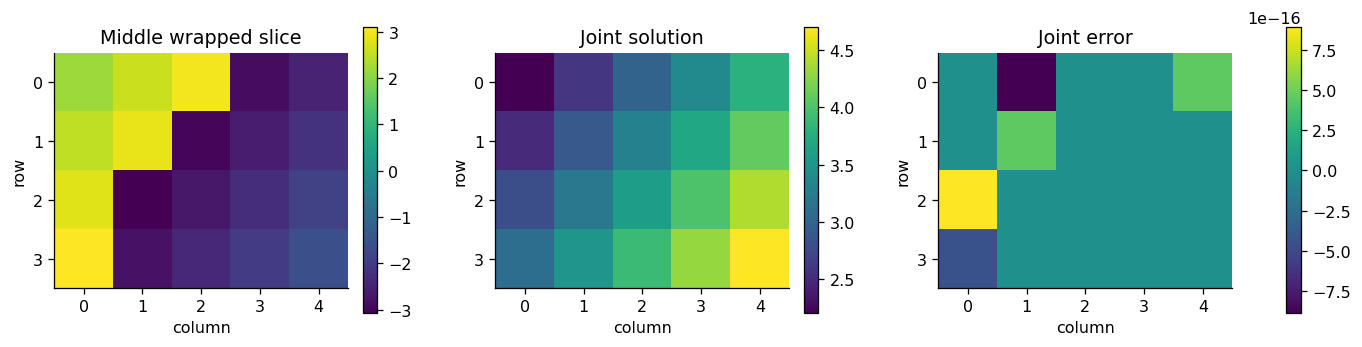

Joint aligned RMSE: 3.9033085706655813e-16


In [3]:
z,y,x=np.indices((3,4,5)); truth=2.2*z+.3*y+.4*x; phase=W(truth)
u,info=pv.flow_nd_unwrap(phase,method='ilp',max_nodes=200,return_info=True)
print(info); assert u.shape==truth.shape
images([phase[1],align(u,truth)[1],(align(u,truth)-truth)[1]],['Middle wrapped slice','Joint solution','Joint error'])
print('Joint aligned RMSE:',pv.rmse_aligned(u,truth))

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

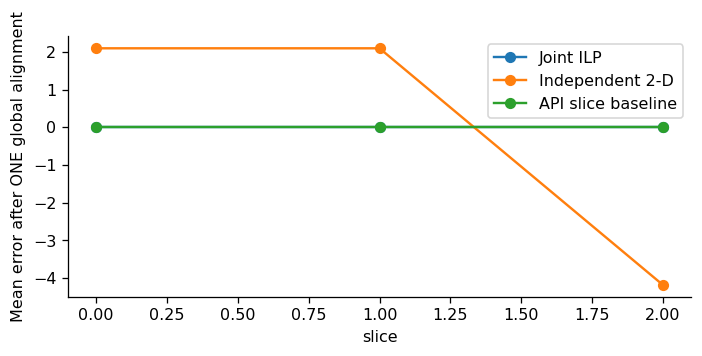

FlowNDInfo(backend='grid-slice', method='slice', cost='linear', shape=(3, 4, 5), pixels=60, nodes=60, edges=133, cycles=36, residues=0, components=1, max_jump=0, objective=0.0, total_variation=0.0, augmentations=0, relaxations=0, proven=True, seeded=False, slices=3)


In [4]:
independent=np.stack([pv.network_flow_unwrap(frame) for frame in phase])
slice_mode,si=pv.flow_nd_unwrap(phase,method='slice',return_info=True)
fig,ax=plt.subplots(figsize=(7,3))
for a,label in [(u,'Joint ILP'),(independent,'Independent 2-D'),(slice_mode,'API slice baseline')]:
    ax.plot(np.mean(align(a,truth)-truth,axis=(1,2)),'o-',label=label)
ax.set(xlabel='slice',ylabel='Mean error after ONE global alignment'); ax.legend(); plt.show()
print(si)

## 5 · Interpretation and limits

Per-slice alignment would hide the relative-offset failure this experiment is
designed to expose. The small smooth volume keeps exact search inexpensive;
noisy larger volumes can require many relaxations. `max_nodes` can return an
unproven incumbent or raise if no feasible solution is found. Inspect the report.
The public slice mode is specifically a 3-D baseline. Dimension-independent
least squares and reliability sorting remain separate options for large volumes.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`flow_nd.py`](../src/parvaneh/flow_nd.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.